# 📊 GalaxyMatch AI — Exploratory Data Analysis
### Member 1 · Data Engineer Deliverable

This notebook explores the cleaned Samsung Galaxy smartphone dataset (`cleaned_dataset.csv`) ahead of feature scoring and the Weighted Sum recommendation model.

**Charts covered:**
1. Price Distribution
2. Battery Capacity Distribution
3. RAM Comparison
4. Price vs Camera Analysis
5. Target Segment Distribution
6. Correlation Heatmap

**Tech stack:** Python · Pandas · NumPy · Matplotlib (per project README)


## 0. Setup & Theme\nSamsung-branded color palette so every chart in the project (EDA + UI) is visually consistent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline

SAMSUNG_BLUE   = "#1428A0"
SAMSUNG_LBLUE  = "#4C6FFF"
SAMSUNG_SKY    = "#7FA6FF"
SAMSUNG_BLACK  = "#0A0A0A"
SAMSUNG_GRAY   = "#5C5C5C"
SAMSUNG_LGRAY  = "#EAEAEA"
BG             = "#F7F8FC"

SEGMENT_COLORS = {
    "budget":       "#8FA6FF",
    "gaming":       "#1428A0",
    "photography":  "#00C2CB",
    "business":     "#0A0A0A",
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": "white",
    "axes.edgecolor": SAMSUNG_LGRAY,
    "axes.labelcolor": SAMSUNG_BLACK,
    "axes.titlecolor": SAMSUNG_BLACK,
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.color": SAMSUNG_GRAY,
    "ytick.color": SAMSUNG_GRAY,
    "grid.color": SAMSUNG_LGRAY,
    "grid.linewidth": 0.8,
    "figure.dpi": 120,
})

def style_axes(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, pad=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.5)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(SAMSUNG_LGRAY)


## 1. Load Cleaned Dataset

In [1]:
df = pd.read_csv("data/cleaned_dataset.csv")
df["price_k"] = df["price_inr"] / 1000

print(f"Dataset shape: {df.shape}")
df.head()

## 2. Price Distribution
How Galaxy device prices are spread across the lineup — from budget A-series to flagship Ultra/Fold-Flip models.

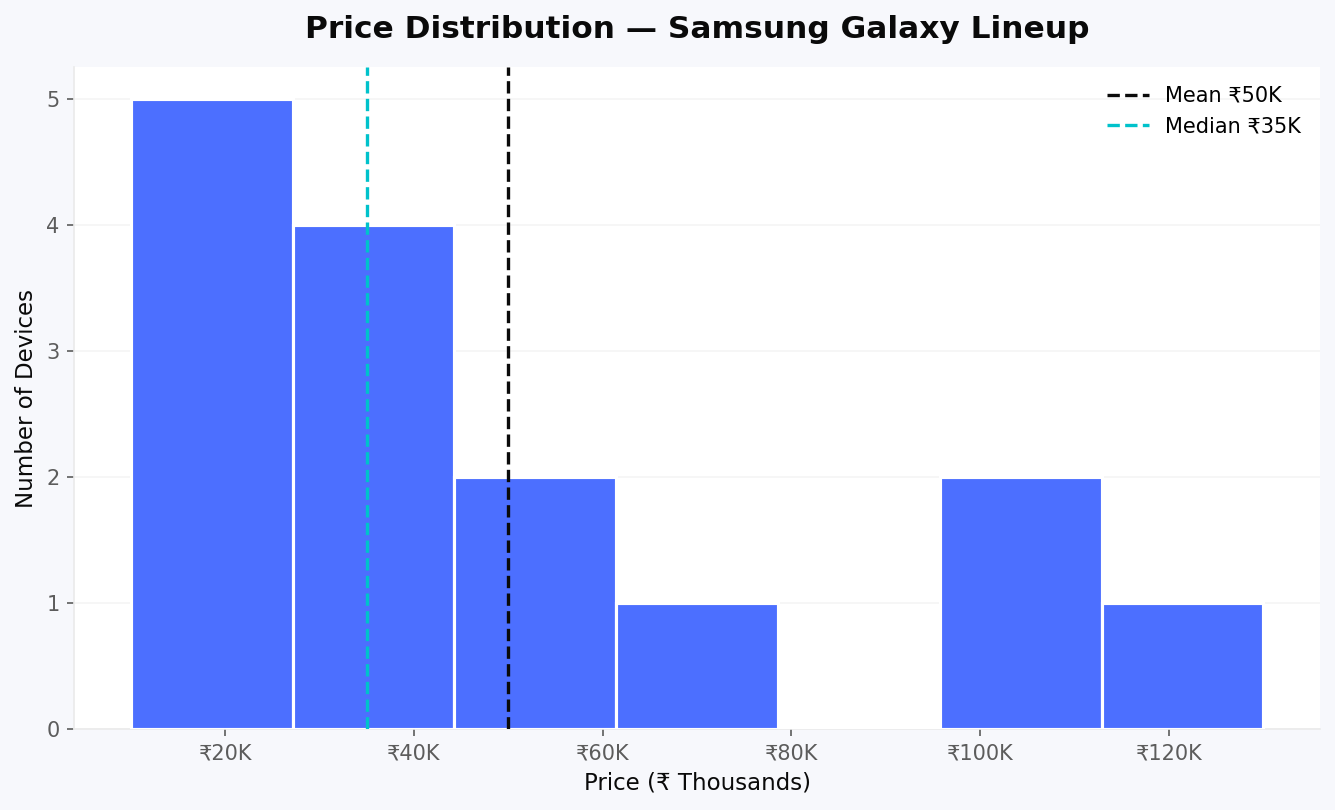

In [1]:
# 1. PRICE DISTRIBUTION\nplt.show()

**Reading it:** The lineup skews heavily toward the sub-₹45K range (A/M-series), with a long tail out to the S24 Ultra and Z Flip6 near ₹1.1–1.3L. Mean sits above median — a few flagship prices pull the average up, so median is the more representative "typical price" for this catalog.

## 3. Battery Capacity Distribution
Battery capacity (mAh) grouped by target segment — useful since "battery" is a direct scoring weight for gaming and budget personas.

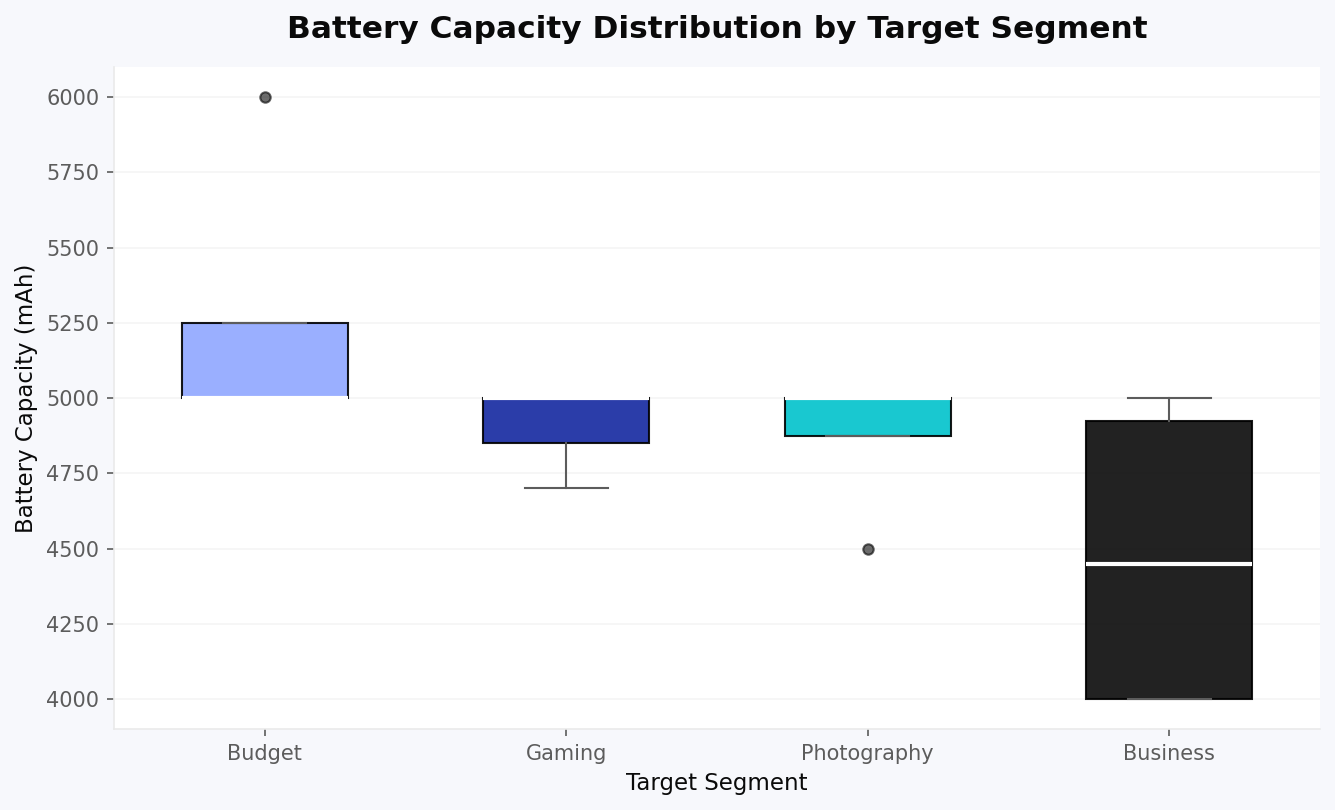

In [1]:
# 2. BATTERY CAPACITY DISTRIBUTION (by segment)\nplt.show()

**Reading it:** Budget and gaming-segment phones cluster tightly around 5,000–6,000 mAh — Samsung standardizes battery capacity low-to-mid range. Business-segment devices (S24, S24+, Z Flip6) show more spread and generally *lower* capacity, trading battery size for slimmer form factors (notably the foldable).

## 4. RAM Comparison
RAM (GB) across all models, colored by target segment, sorted ascending.

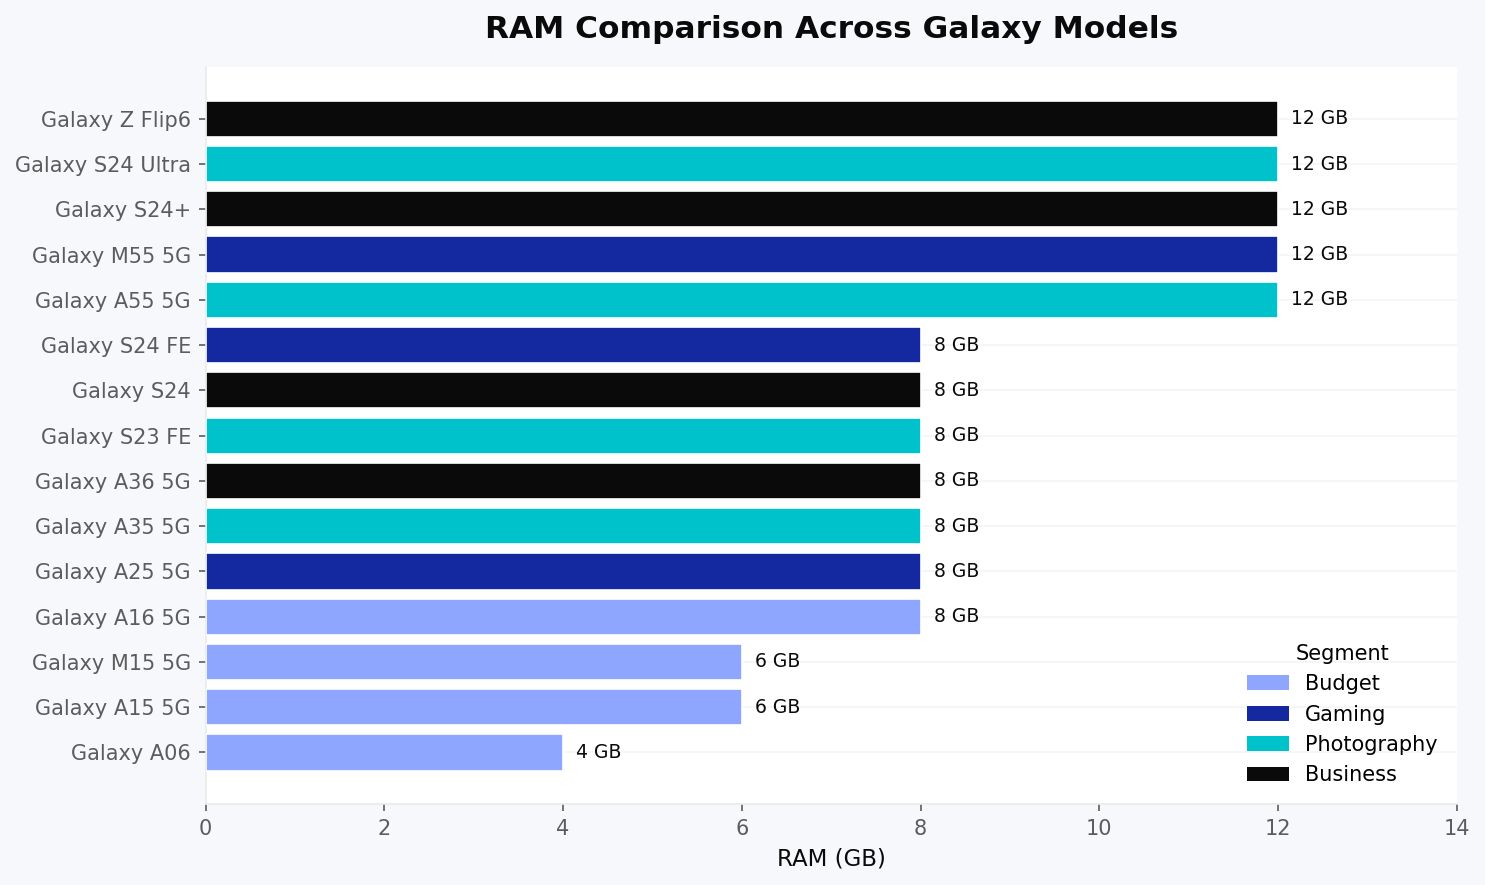

In [1]:
# 3. RAM COMPARISON\nplt.show()

**Reading it:** RAM scales cleanly with price tier: 4–8GB for budget A/M-series, 8–12GB from the A55/S23 FE tier upward. The S24+ and S24 Ultra top out at 12GB, matching their flagship/business+photography positioning.

## 5. Price vs Camera Analysis
Relationship between camera resolution (MP) and price, bubble size scaled by battery score, colored by segment.

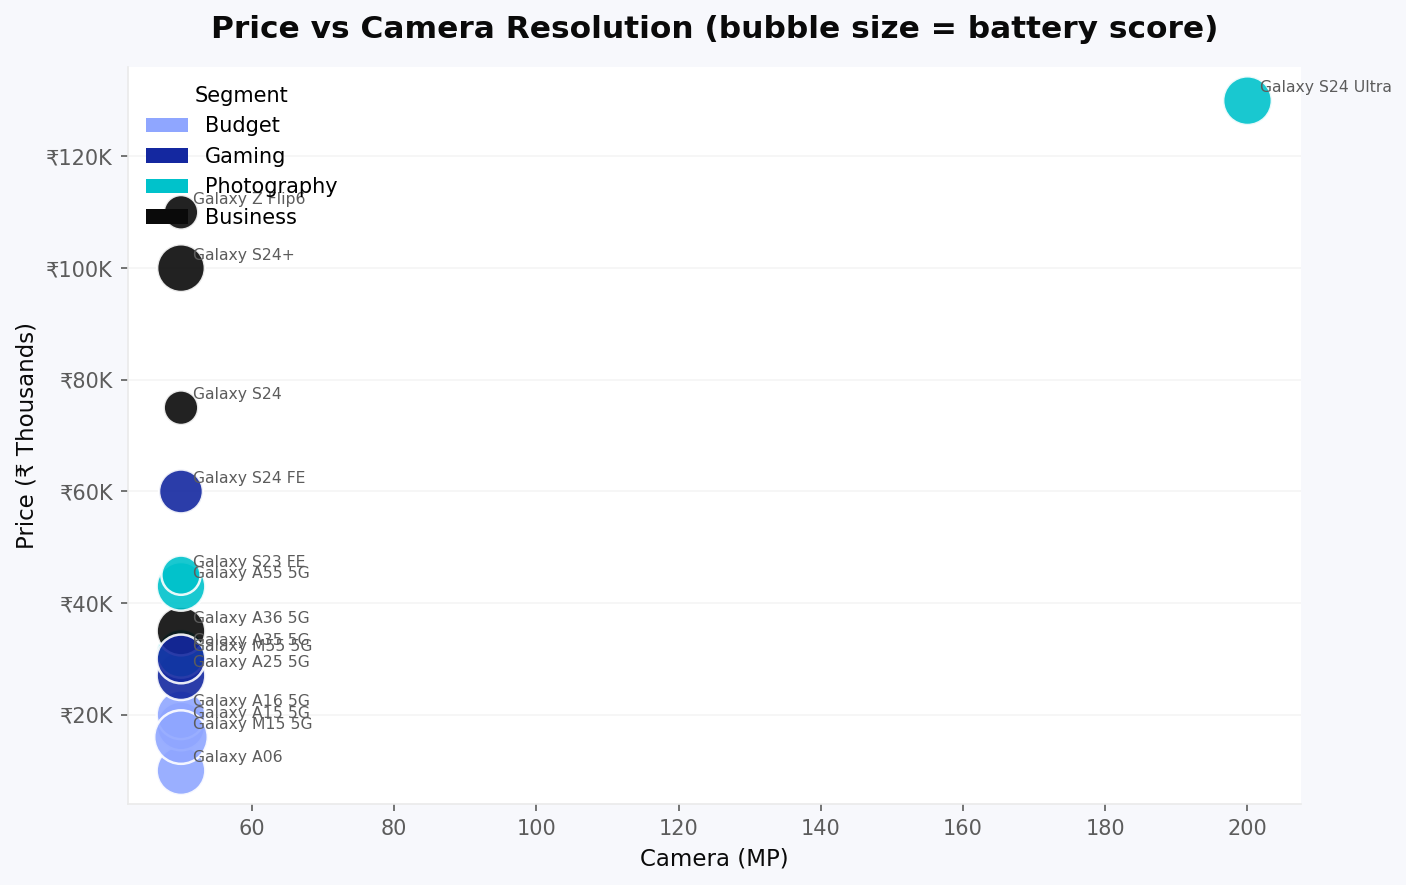

In [1]:
# 4. PRICE VS CAMERA ANALYSIS\nplt.show()

**Reading it:** Most of the lineup sits flat at 50MP regardless of price — camera MP alone barely separates budget from flagship. The S24 Ultra is the clear outlier at 200MP, justifying a camera-score premium in the Weighted Sum model beyond just megapixels (this is why `camera_score` also folds in sensor/processing quality, not raw MP).

## 6. Target Segment Distribution
Share of catalog devices per target persona (budget / gaming / photography / business).

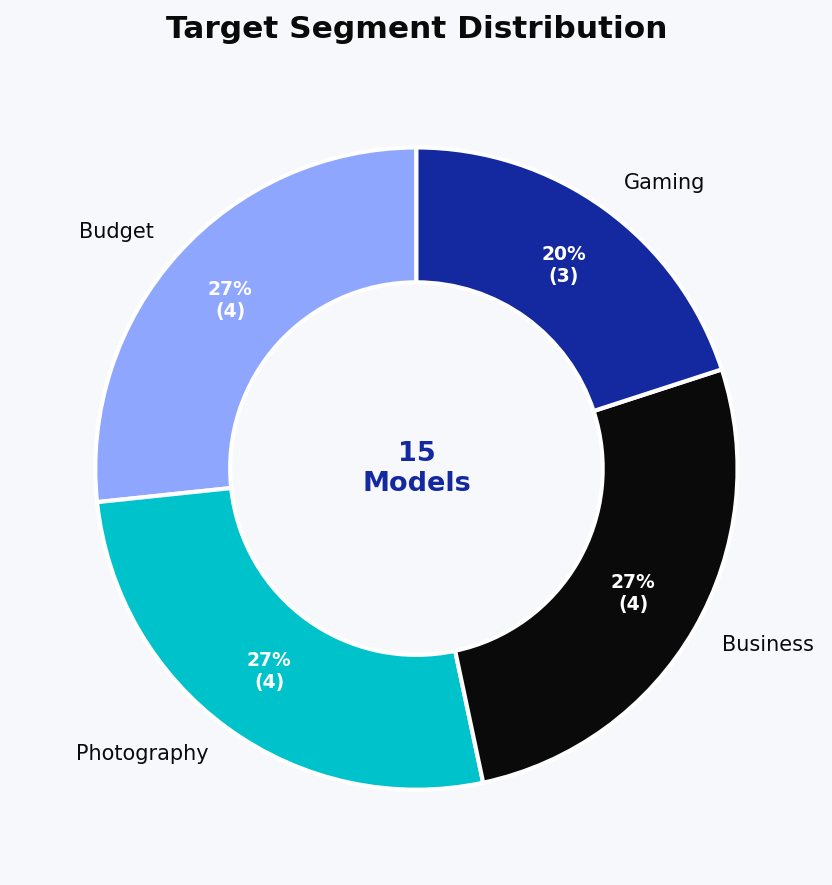

In [1]:
# 5. TARGET SEGMENT DISTRIBUTION\nplt.show()

**Reading it:** The catalog is reasonably balanced across personas, with budget and photography slightly ahead — sensible for a recommendation demo since it avoids the model defaulting toward one segment due to data imbalance.

## 7. Correlation Heatmap
Pairwise correlation across all numeric spec and engineered-score columns — sanity-checks the feature engineering going into the Weighted Sum Model.

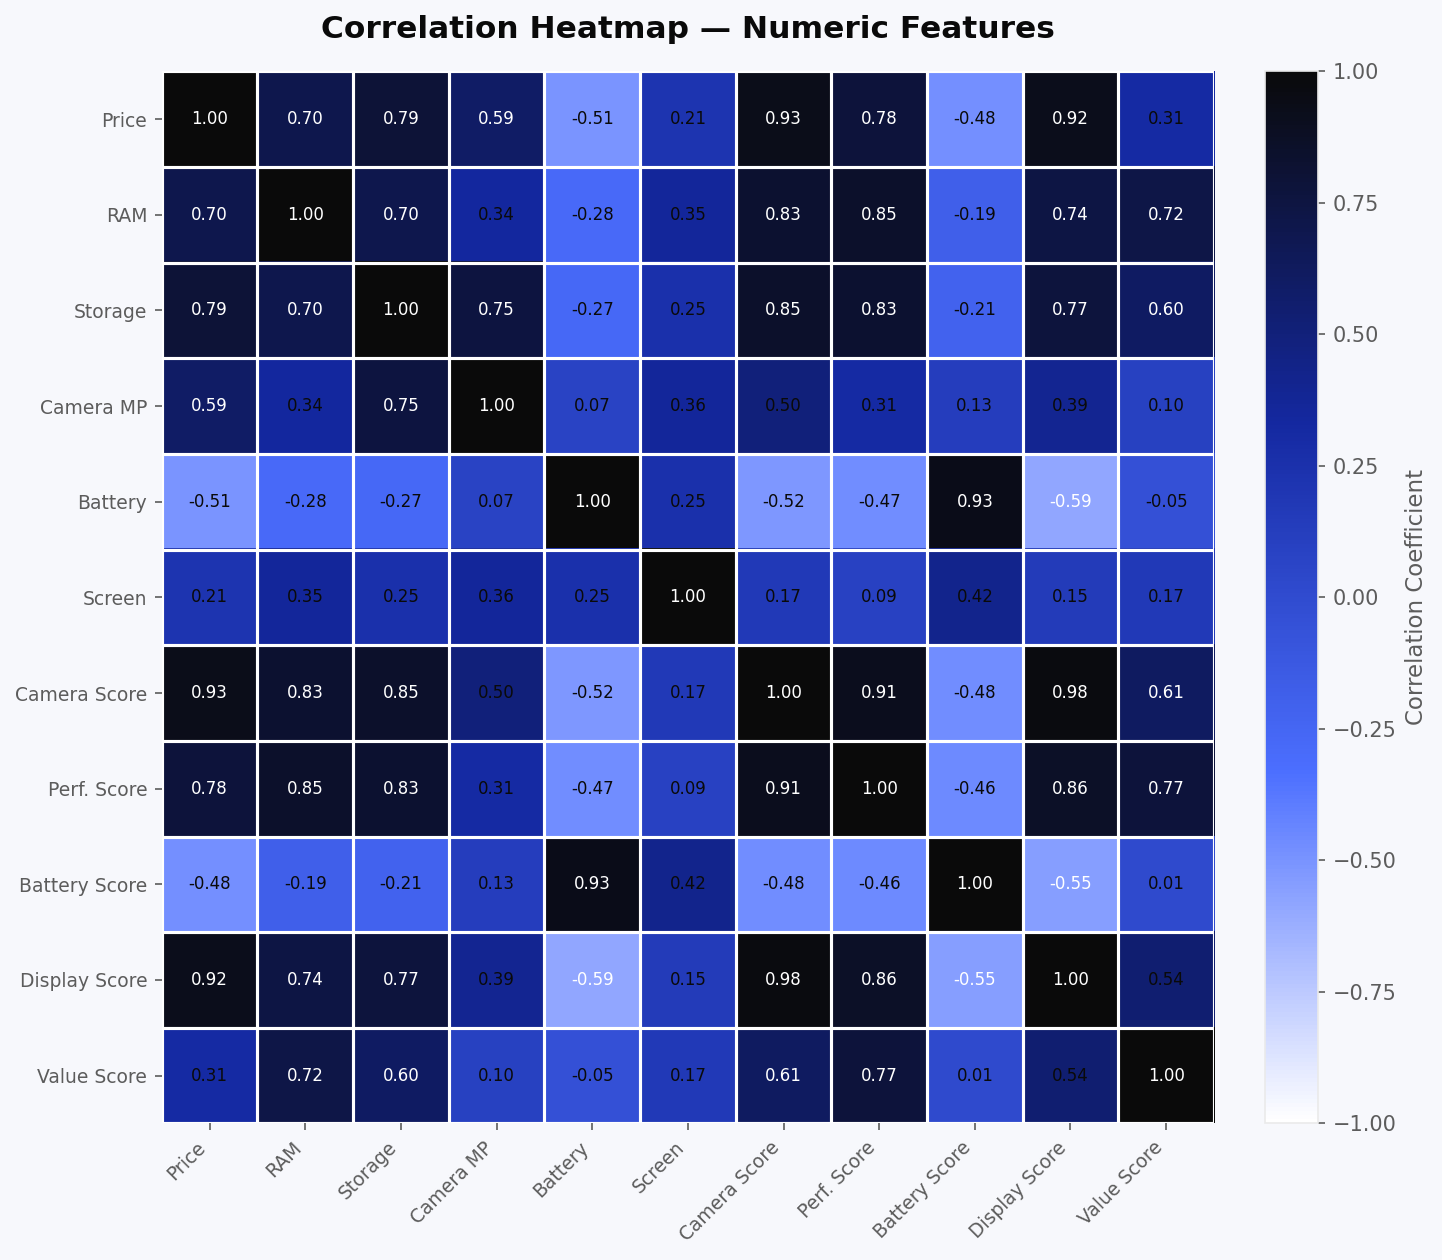

In [1]:
# 6. CORRELATION HEATMAP\nplt.show()

**Reading it:**
- **Price ↔ Performance Score / RAM** are the strongest positive correlations — expected, since Samsung prices heavily on chipset + memory tier.
- **Battery Score is nearly uncorrelated with Price** (~flat) — confirms battery isn't a premium-tier differentiator here, which is why it's a *separate* weighted factor rather than something Price already captures.
- **Value Score correlates positively with Camera/Performance/Display Scores but only weakly with Price** — indicates the value_score formula is already normalizing for cost, not just rewarding expensive phones.

These relationships validate that `camera_score`, `battery_score`, `performance_score`, and `display_score` are contributing *distinct* signal to the Weighted Sum Model rather than being redundant proxies for price.

## 8. Summary — Handoff to Member 2 (Recommendation Engineer)

- Dataset is clean: 15 Galaxy models, no missing values, 4 target segments.
- Price is right-skewed → median, not mean, should anchor any "budget cutoff" logic in the recommender.
- Engineered scores (camera/performance/battery/display/value) are **not redundant with price** — validated via correlation heatmap — so all four are safe to use as independent weighted factors.
- Segment distribution is balanced enough for persona-based weight presets (Photography / Gaming / Business / Budget) to each have real supporting data.

Next: feed `cleaned_dataset.csv` + these engineered scores into the Weighted Sum Model (`src/scoring.py`, `src/recommendation.py`).